# OpenFoodFacts Global Nutrition Analysis

## Notebook 3: Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned OpenFoodFacts dataset through descriptive statistics and visual analysis. Exploratory Data Analysis (EDA) helps identify patterns, trends, distributions, and relationships among nutritional and categorical variables before drawing meaningful insights.

### Workflow

- Import the required libraries
- Configure notebook display settings
- Load the cleaned dataset
- Create a working copy
- Examine dataset dimensions
- Display the first few records
- Review dataset information
- Generate descriptive statistics
- Explore numerical variables
- Explore categorical variables
- Analyze missing values
- Study nutritional distributions
- Examine feature relationships
- Identify potential outliers
- Summarize the key findings

## Importing the Required Libraries

In this section, we import the Python libraries required for exploratory data analysis. These libraries provide tools for data manipulation, statistical summaries, and visualization throughout the notebook.

In [ ]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Configuring Notebook Display Settings

To improve readability during exploratory analysis, we configure display options that allow more rows, columns, and longer text values to be displayed without truncation.

In [2]:
# Configure notebook display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 100)
plt.style.use("default")

## Loading the Cleaned Dataset

The cleaned dataset generated during the preprocessing stage is loaded into a Pandas DataFrame. This dataset serves as the foundation for all exploratory analyses performed in this notebook.

In [3]:
# Load the cleaned dataset

food_df = pd.read_csv("../data/processed/openfoodfacts_cleaned.csv", low_memory = False)

## Creating a Working Copy of the Dataset

A separate working copy of the cleaned dataset is created to preserve the original cleaned data while allowing exploratory analysis to be performed safely.

In [4]:
# Create a working copy of the dataset

eda_df = food_df.copy()

## Examining Dataset Dimensions

Before performing exploratory analysis, we examine the dimensions of the cleaned dataset. This provides the total number of observations and variables available for analysis.

In [5]:
# Display the dataset dimensions

eda_df.shape

(356027, 64)

## Displaying the First Few Records

Before performing detailed analysis, we display the first few records of the cleaned dataset. This provides an initial understanding of the dataset structure, available variables, and the format of the stored values.

In [6]:
# Display the first five records of the dataset

eda_df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,allergens,serving_size,additives_n,additives,additives_tags,additives_en,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_en,main_category,main_category_en,image_url,image_small_url,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
0,0000000003087,http://world-en.openfoodfacts.org/product/0000000003087/farine-de-ble-noir-ferme-t-y-r-nao,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,NaN,NaN,Ferme t'y R'nao,ferme-t-y-r-nao,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-completed, en:ingredients-to-be-completed, en:expir...","en:to-be-completed,en:nutrition-facts-to-be-completed,en:ingredients-to-be-completed,en:expirati...","To be completed,Nutrition facts to be completed,Ingredients to be completed,Expiration date to b...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000000004530,http://world-en.openfoodfacts.org/product/0000000004530/banana-chips-sweetened-whole,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,US,en:united-states,United States,"Bananas, vegetable oil (coconut oil, corn oil and/or palm oil) sugar, natural banana flavor.",NaN,28 g (1 ONZ),0.0,[ bananas -> en:bananas ] [ vegetable-oil -> en:vegetable-oil ] [ oil -> en:oil ] [ cocon...,NaN,NaN,0.0,0.0,d,NaN,NaN,"en:to-be-completed, en:nutrition-facts-completed, en:ingredients-completed, en:expiration-date-t...","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-to-b...","To be completed,Nutrition facts completed,Ingredients completed,Expiration date to be completed,...",NaN,NaN,NaN,NaN,2243.0,28.57,28.57,0.0,0.018,64.29,14.29,3.6,3.57,0.00000,0.000,0.0,0.0214,NaN,0.000,0.00129,14.0,14.0
2,0000000004559,http://world-en.openfoodfacts.org/product/0000000004559/peanuts-torn-glasser,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,NaN,NaN,NaN,NaN,Torn & Glasser,torn-glasser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,US,en:united-states,United States,"Peanuts, wheat flour, sugar, rice flour, tapioca starch, salt, leavening (ammonium bicarbonate, ...",NaN,28 g (0.25 cup),0.0,[ peanuts -> en:peanuts ] [ wheat-flour -> en:wheat-flour ] [ flour -> en:flour ] [ sugar...,NaN,NaN,0.0,0.0,b,NaN,NaN,"en:to-be-completed, en:nutrition-facts-completed, en:ingredients-completed, en:expiration-date-t...","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-to-b...","To be completed,Nutrition facts completed,Ingredients completed,Expiration date to be completed,...",NaN,NaN,NaN,NaN,1941.0,17.86,0.00,0.0,0.000,60.71,17.86,7.1,17.86,0.63500,0.250,0.0,0.0000,NaN,0.071,0.00129,0.0,0.0
3,0000000016087,http://world-en.openfoodfacts.org/product/0000000016087/organic-salted-nut-mix-grizzlies,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,NaN,NaN,NaN,NaN,Grizzlies,grizzlies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,US,en:united-states,United States,"Organic hazelnuts, organic cashews, organic walnuts almonds, organic sunflow

## Reviewing Dataset Information

We examine the dataset information to understand the remaining variables, their data types, and the number of non-null values after preprocessing. This confirms that the cleaned dataset is ready for exploratory analysis.

In [7]:
# Display dataset information

eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356027 entries, 0 to 356026
Data columns (total 64 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   code                                     356001 non-null  object 
 1   url                                      356001 non-null  object 
 2   creator                                  356024 non-null  object 
 3   created_t                                356024 non-null  object 
 4   created_datetime                         356017 non-null  object 
 5   last_modified_t                          356027 non-null  object 
 6   last_modified_datetime                   356027 non-null  object 
 7   product_name                             338515 non-null  object 
 8   generic_name                             57714 non-null   object 
 9   quantity                                 119285 non-null  object 
 10  packaging                       

## Generating Descriptive Statistics

Descriptive statistics provide a summary of the numerical variables in the dataset. Measures such as count, mean, standard deviation, minimum, maximum, and quartiles help understand the overall distribution of nutritional attributes.

In [8]:
# Generate descriptive statistics for numerical variables

eda_df.describe()

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
count,283867.000000,283867.000000,283867.000000,295367.000000,2.794970e+05,263823.000000,143443.000000,144170.000000,2.792200e+05,279186.000000,2.206830e+05,2.941610e+05,289739.000000,289694.000000,137706.000000,141060.000000,24848.000000,141517.000000,140660.000000,254856.000000,254856.000000
mean,1.876851,0.023430,0.059736,1125.453320,5.606587e+04,5.092460,0.073487,0.020065,5.614020e+04,15.673428,3.843467e+05,5.326598e+04,1.941281,0.764401,0.000398,0.023394,0.424284,0.127284,0.003791,9.166137,8.980656
std,2.501022,0.153094,0.280660,936.825952,2.963385e+07,7.965148,1.539417,0.357963,2.964854e+07,21.983635,1.805529e+08,2.888578e+07,120.545973,47.462729,0.073239,2.234928,12.503642,3.349236,0.216565,8.999870,9.151757
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-3.570000,0.000000,0.000000e+00,-17.860000,-6.700000e+00,-8.000000e+02,0.000000,0.000000,-0.000340,-0.002100,0.000000,0.000000,-0.000260,-15.000000,-15.000000
25%,0.000000,0.000000,0.000000,382.000000,1.000000e-01,0.000000,0.000000,0.000000,5.600000e+00,1.200000,0.000000e+00,7.200000e-01,0.060000,0.023622,0.000000,0.000000,0.106000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,0.000000,0.000000,1092.000000,5.290000e+00,1.790000,0.000000,0.000000,2.000000e+01,5.400000,1.500000e+00,4.880000e+00,0.558800,0.220000,0.000000,0.000000,0.180000,0.036000,0.001010,10.000000,9.000000
75%,3.000000,0.000000,0.000000,1674.000000,2.000000e+01,7.140000,0.000000,0.020000,5.758000e+01,23.330000,3.600000e+00,1.000000e+01,1.356360,0.534000,0.000107,0.003800,0.341000,0.107000,0.002400,16.000000,16.000000
max,30.000000,2.000000,6.000000,231199.000000,1.566667e+10,550.000000,369.000000,95.238000,1.566667e+10,3520.000000,8.481815e+10,1.566667e+10,64312.800000,25320.000000,26.700000,716.981100,1870.370000,694.737000,50.000000,40.000000,40.000000


## Separating Numerical and Categorical Variables

Before performing detailed exploratory analysis, we separate the numerical and categorical variables in the dataset. This makes it easier to analyze each group using appropriate statistical methods and visualizations.

In [9]:
# Identify numerical and categorical columns

numerical_columns = eda_df.select_dtypes(include = ["number"]).columns
categorical_columns = eda_df.select_dtypes(include = ["object"]).columns

## Counting Numerical and Categorical Variables

We count the number of numerical and categorical variables present in the cleaned dataset. This provides a quick overview of the dataset structure before exploring each variable type separately.

In [10]:
# Display the number of numerical and categorical columns

print(f"Numerical columns   : {len(numerical_columns)}")
print(f"categorical columns : {len(categorical_columns)}")

Numerical columns   : 21
categorical columns : 43


## Displaying Numerical Variables

The numerical variables represent quantitative nutritional measurements such as energy, fat, carbohydrates, protein, vitamins, and mineral content. Listing these variables helps identify the measurements available for statistical analysis.

In [11]:
# Display numerical column names

list(numerical_columns)

['additives_n',
 'ingredients_from_palm_oil_n',
 'ingredients_that_may_be_from_palm_oil_n',
 'energy_100g',
 'fat_100g',
 'saturated-fat_100g',
 'trans-fat_100g',
 'cholesterol_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'fiber_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g',
 'vitamin-a_100g',
 'vitamin-c_100g',
 'potassium_100g',
 'calcium_100g',
 'iron_100g',
 'nutrition-score-fr_100g',
 'nutrition-score-uk_100g']

## Displaying Categorical Variables

The categorical variables describe product information such as product names, brands, categories, countries, packaging details, and nutrition grades. Listing these variables helps identify the descriptive attributes available for exploration.

In [12]:
# Display categorical column names

list(categorical_columns)

['code',
 'url',
 'creator',
 'created_t',
 'created_datetime',
 'last_modified_t',
 'last_modified_datetime',
 'product_name',
 'generic_name',
 'quantity',
 'packaging',
 'packaging_tags',
 'brands',
 'brands_tags',
 'categories',
 'categories_tags',
 'categories_en',
 'manufacturing_places',
 'manufacturing_places_tags',
 'labels',
 'labels_tags',
 'labels_en',
 'purchase_places',
 'stores',
 'countries',
 'countries_tags',
 'countries_en',
 'ingredients_text',
 'allergens',
 'serving_size',
 'additives',
 'additives_tags',
 'additives_en',
 'nutrition_grade_fr',
 'pnns_groups_1',
 'pnns_groups_2',
 'states',
 'states_tags',
 'states_en',
 'main_category',
 'main_category_en',
 'image_url',
 'image_small_url']

## Exploring the Distribution of Numerical Variables

To better understand the numerical features in the dataset, we examine their statistical distributions. This analysis helps identify the range, central tendency, variability, and potential anomalies present in the nutritional attributes.

In [13]:
# Display descriptive statistics for numerical variables

eda_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
additives_n,283867.0,1.876851,2.501022e+00,0.00000,0.000000,1.00000,3.000000,3.000000e+01
ingredients_from_palm_oil_n,283867.0,0.023430,1.530938e-01,0.00000,0.000000,0.00000,0.000000,2.000000e+00
ingredients_that_may_be_from_palm_oil_n,283867.0,0.059736,2.806595e-01,0.00000,0.000000,0.00000,0.000000,6.000000e+00
energy_100g,295367.0,1125.453320,9.368260e+02,0.00000,382.000000,1092.00000,1674.000000,2.311990e+05
fat_100g,279497.0,56065.871771,2.963385e+07,0.00000,0.100000,5.29000,20.000000,1.566667e+10
saturated-fat_100g,263823.0,5.092460,7.965148e+00,0.00000,0.000000,1.79000,7.140000,5.500000e+02
trans-fat_100g,143443.0,0.073487,1.539417e+00,-3.57000,0.000000,0.00000,0.000000,3.690000e+02
cholesterol_100g,144170.0,0.020065,3.579628e-01,0.00000,0.000000,0.00000,0.020000,9.523800e+01
carbohydrates_100g,279220.0,56140.201581,2.964854e+07,0.00000,5.600000,20.00000,57.580000,1.566667e+10
sugars_100g,279186.0,15.673428,2.198364e+01,-17.86000,1.200000,5.40000,23.330000,3.520000e+03


## Identifying Numerical Variables with Missing Values

Although the dataset has been preprocessed, some numerical variables still contain missing values. Identifying these variables helps determine which measurements have incomplete observations and should be interpreted with appropriate caution during analysis.

In [14]:
# Count missing values in numerical columns

numerical_missing = eda_df[numerical_columns].isnull().sum()
numerical_missing = numerical_missing[numerical_missing > 0]
numerical_missing.sort_values(ascending = False)

potassium_100g                             331179
vitamin-a_100g                             218321
iron_100g                                  215367
vitamin-c_100g                             214967
calcium_100g                               214510
trans-fat_100g                             212584
cholesterol_100g                           211857
fiber_100g                                 135344
nutrition-score-uk_100g                    101171
nutrition-score-fr_100g                    101171
saturated-fat_100g                          92204
sugars_100g                                 76841
carbohydrates_100g                          76807
fat_100g                                    76530
ingredients_that_may_be_from_palm_oil_n     72160
ingredients_from_palm_oil_n                 72160
additives_n                                 72160
sodium_100g                                 66333
salt_100g                                   66288
proteins_100g                               61866


## Visualizing Missing Values in Numerical Variables

Although high-missing-value columns were removed during preprocessing, several numerical variables still contain missing observations. Visualizing these missing values provides a clearer understanding of data availability across nutritional attributes.

In [15]:
# Create a DataFrame of missing values in numerical columns

numerical_missing_df = (numerical_missing.sort_values(ascending = False)).reset_index()
numerical_missing_df.columns = ["column", "Missing Values"]

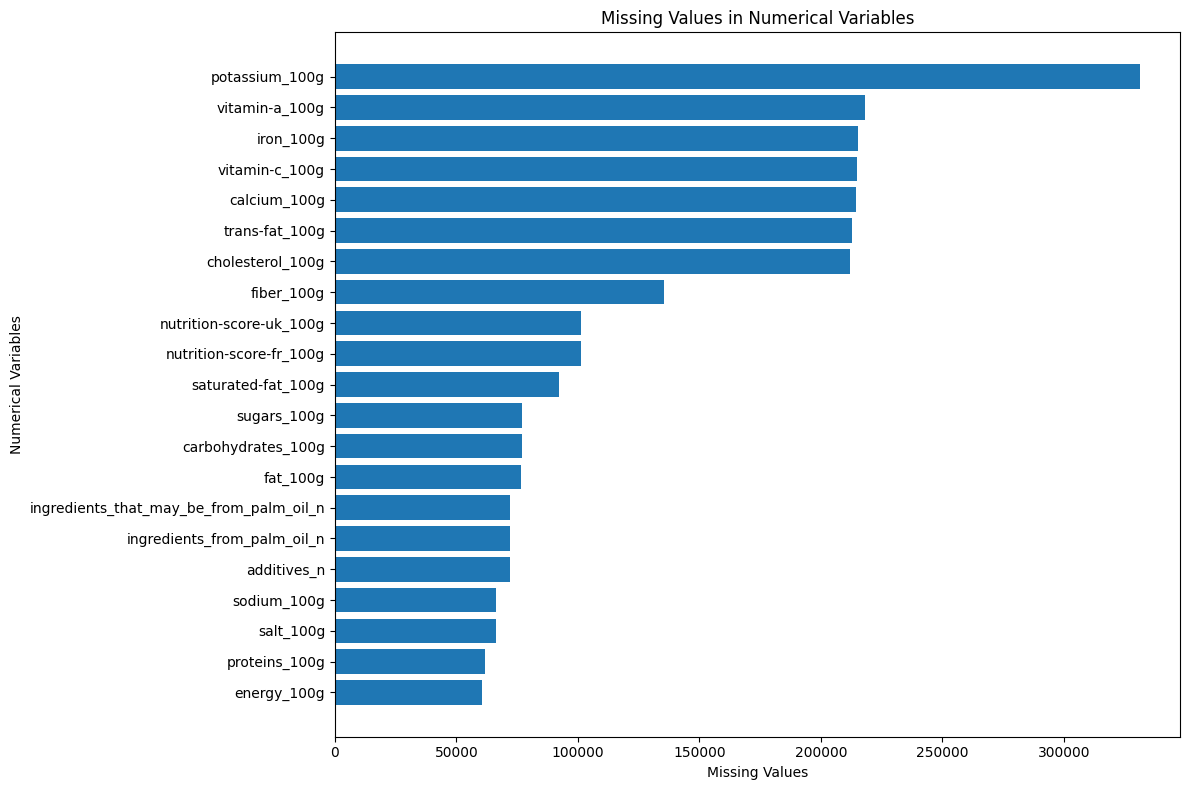

In [16]:
# Create a bar chart of missing values

plt.figure(figsize = (12, 8))
plt.barh(numerical_missing_df["column"], numerical_missing_df["Missing Values"])
plt.xlabel("Missing Values")
plt.ylabel("Numerical Variables")
plt.title("Missing Values in Numerical Variables")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Observation

The visualization shows that some nutritional variables contain substantially more missing observations than others. Variables such as **potassium**, **vitamin A**, **iron**, and **vitamin C** have comparatively fewer recorded values, whereas **energy**, **protein**, **salt**, and **sodium** are available for a much larger proportion of products. These differences should be considered when interpreting subsequent analyses.

## Distribution of Numerical Variables

Understanding the distribution of numerical variables is an important step in exploratory data analysis. Histograms help reveal the spread, central tendency, skewness, and potential outliers within each nutritional variable. This provides insight into the overall characteristics of the dataset before performing deeper statistical analysis.

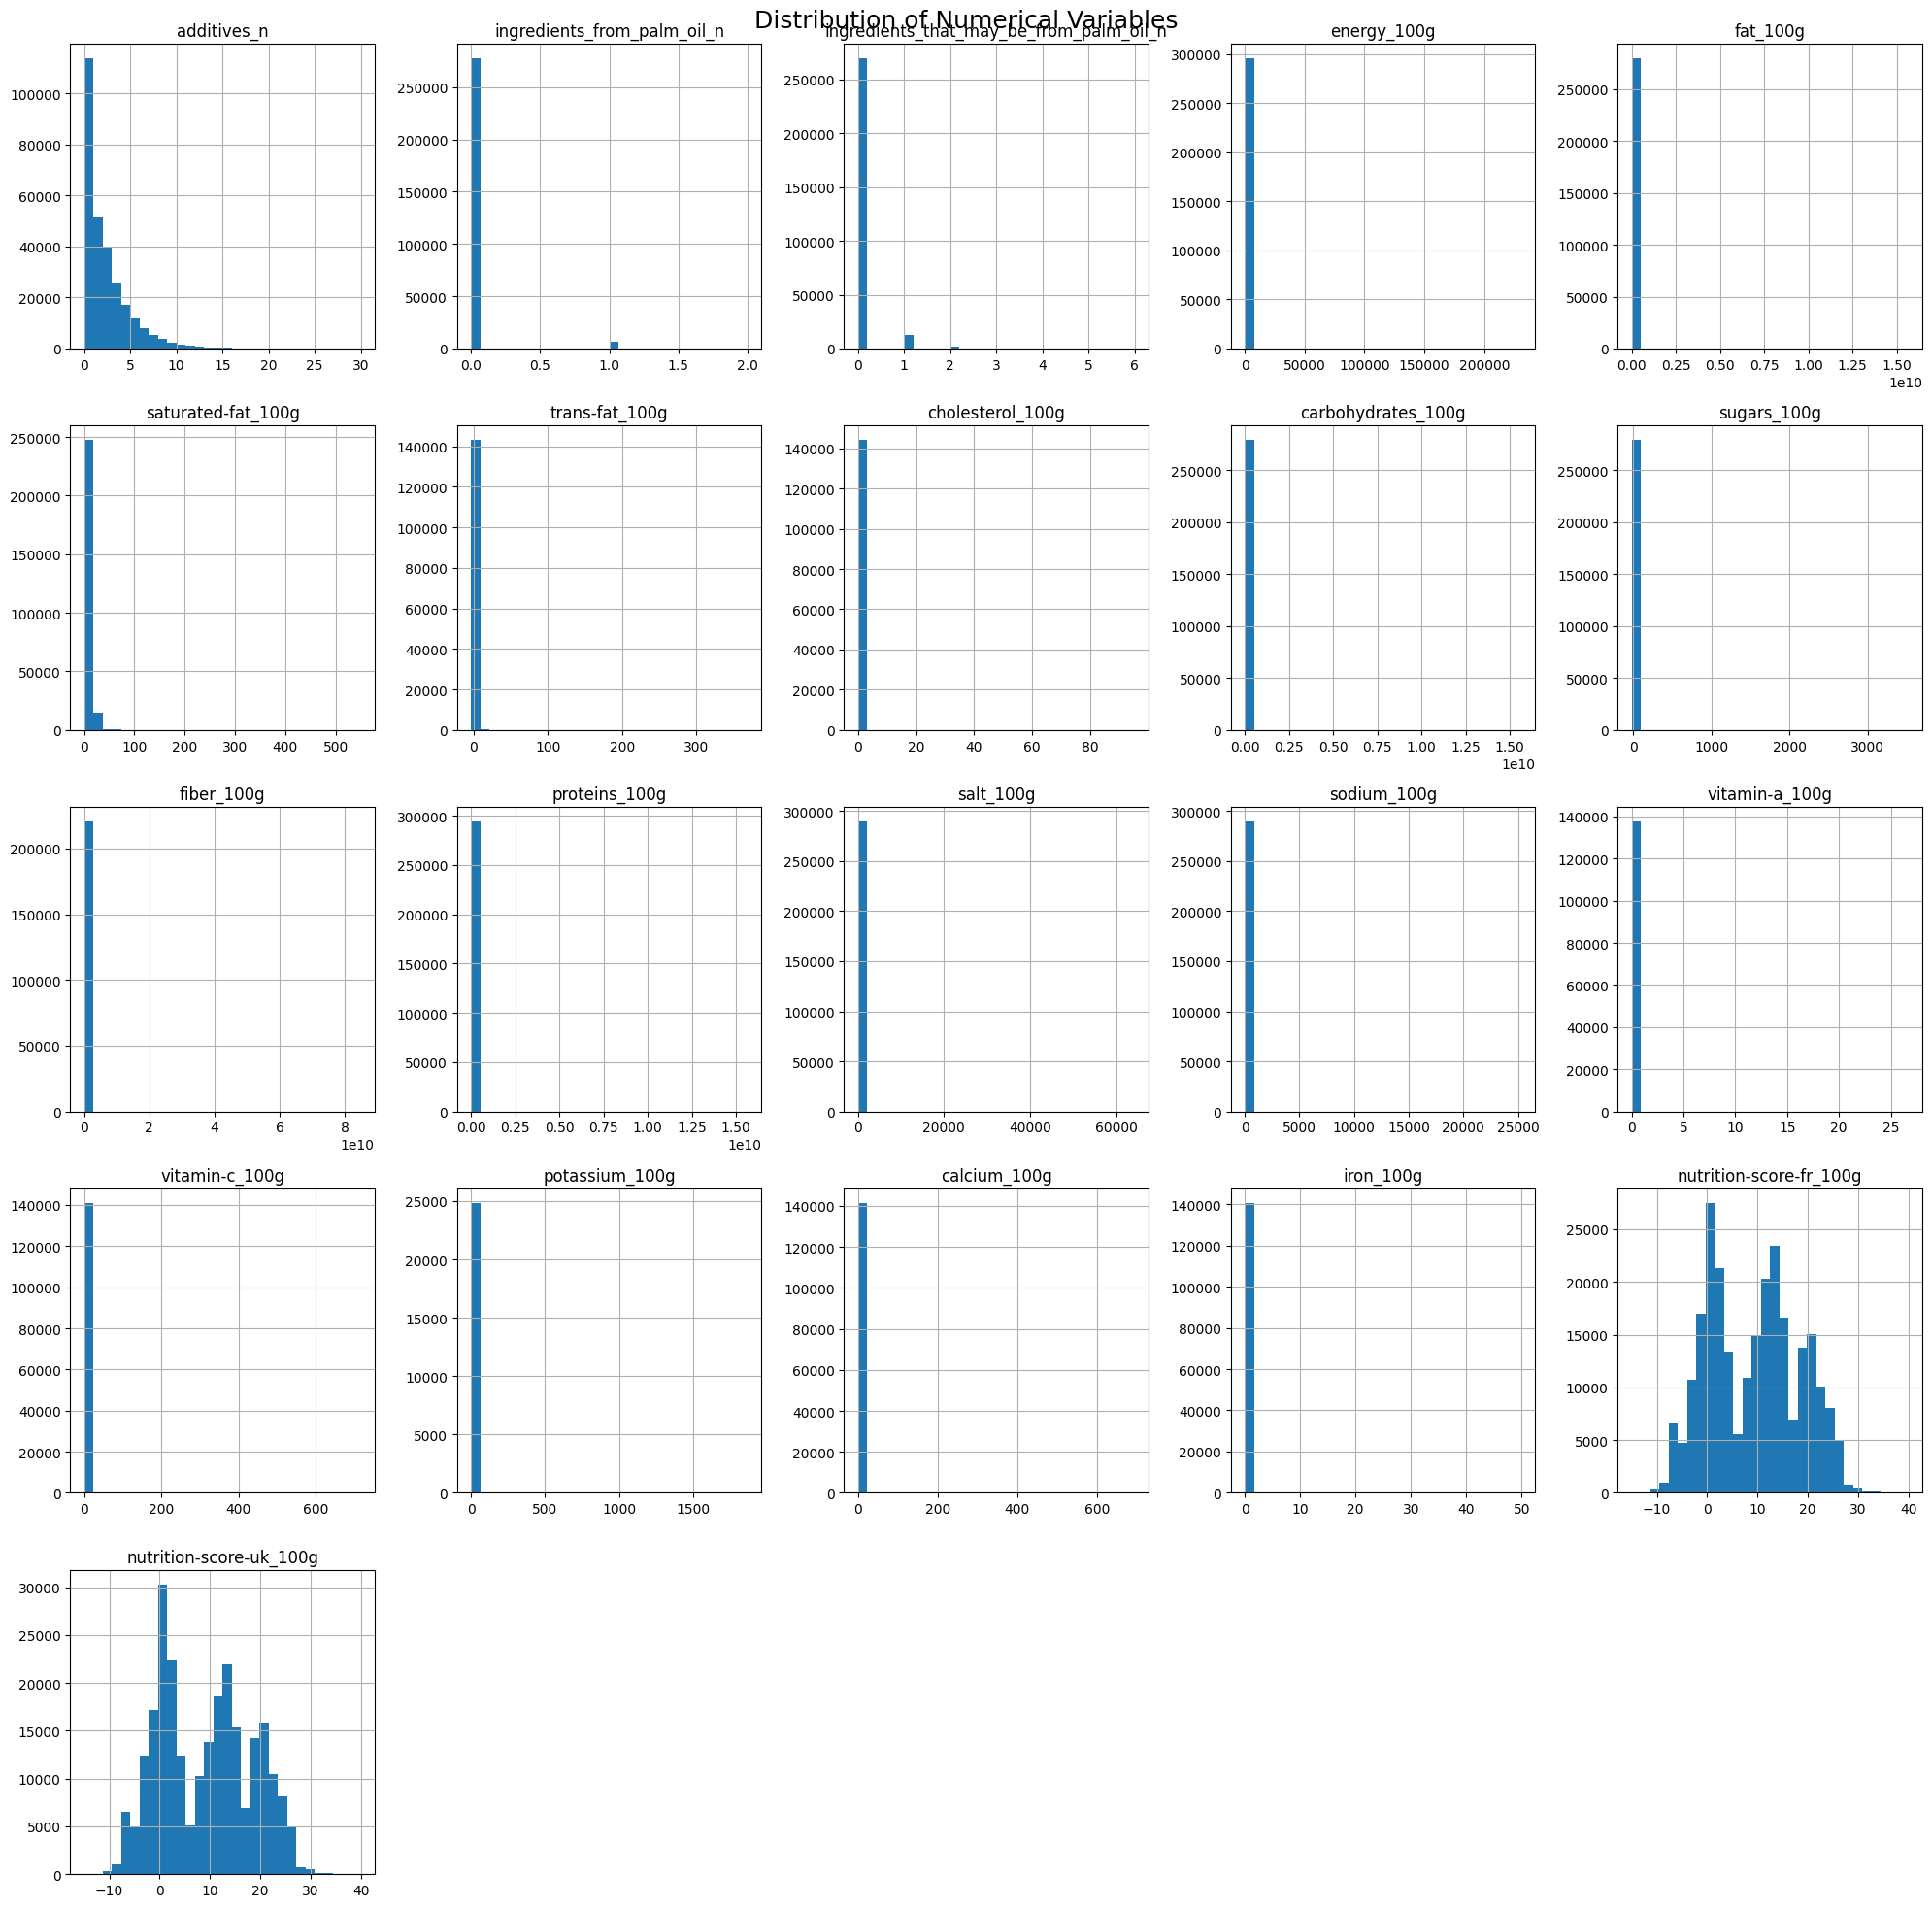

In [17]:
# Display histograms for all numerical variables

eda_df[numerical_columns].hist(figsize = (20, 20), bins = 30)
plt.suptitle("Distribution of Numerical Variables", fontsize = 18)
plt.tight_layout()
plt.show()

### Observation

The distributions indicate that many nutritional variables are highly right-skewed, with a large concentration of products having relatively low values and a small number of products exhibiting extremely high values. Several variables also display noticeable outliers, suggesting that additional investigation through boxplots and summary statistics will provide a clearer understanding of data variability.

## Boxplot Analysis of Numerical Variables

While histograms provide an overview of data distributions, boxplots offer a clearer view of the spread of values and help identify extreme observations. This analysis highlights variables containing potential outliers that may influence statistical summaries and visual interpretations.

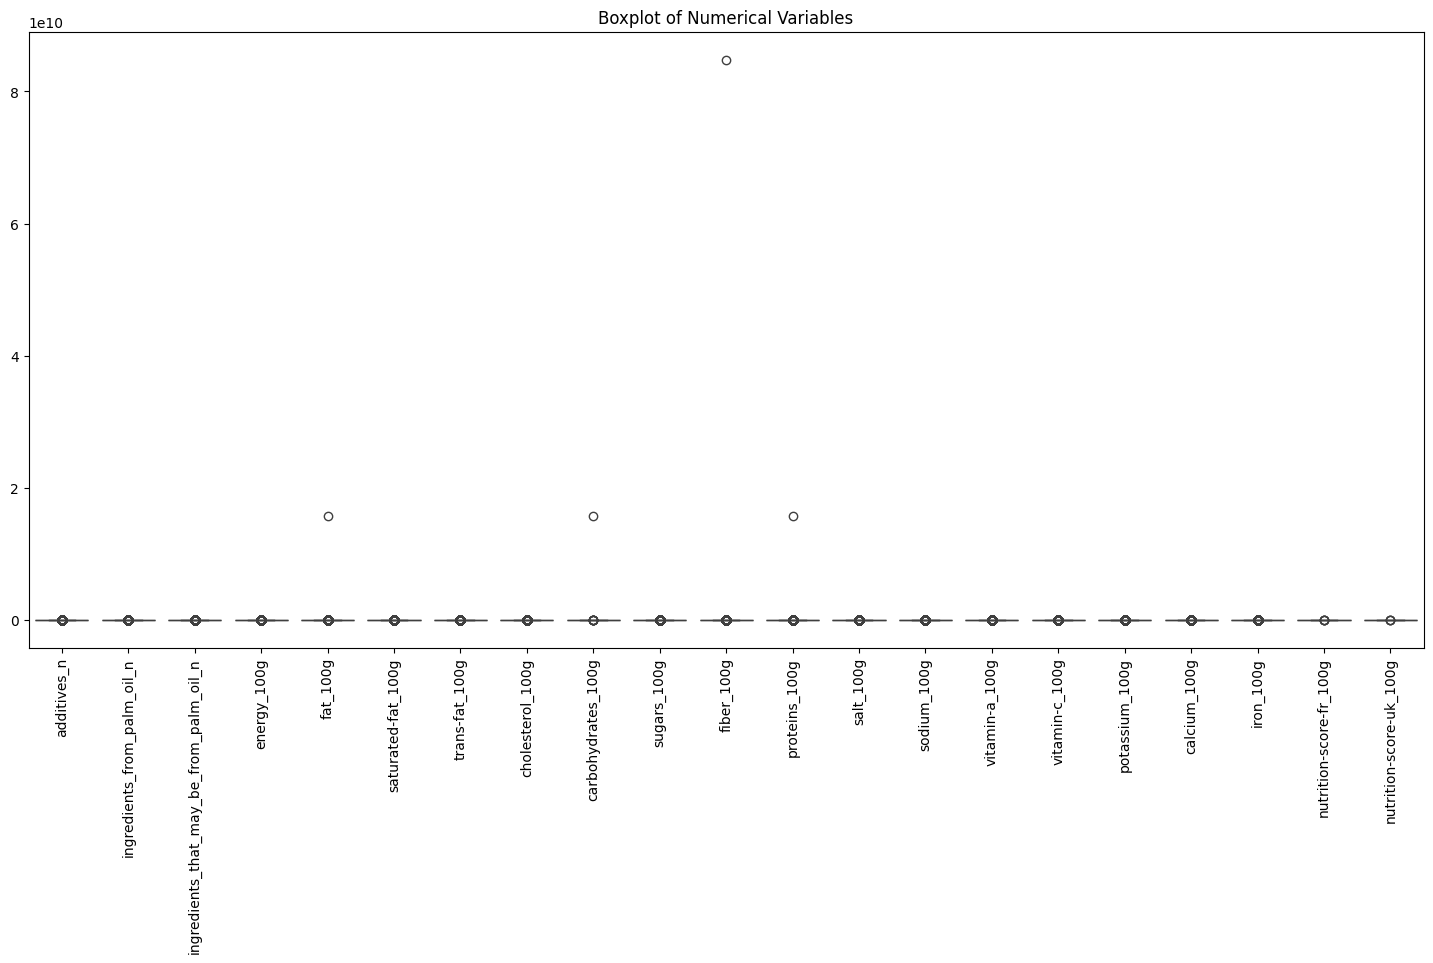

In [18]:
# Create boxplots for all numerical variables

plt.figure(figsize = (18, 8))
sns.boxplot(data = eda_df[numerical_columns])
plt.xticks(rotation = 90)
plt.title("Boxplot of Numerical Variables")
plt.tight_layout
plt.show()

### Observation

The boxplots reveal that many nutritional variables contain substantial outliers, with several products reporting exceptionally large values compared to the majority of observations. These extreme values are consistent with the skewed distributions observed in the histograms and suggest the presence of unusual product entries, reporting inconsistencies, or data quality issues. Since this project focuses on exploratory analysis, these observations are retained for further investigation rather than removed.

## Correlation Analysis of Nutritional Variables

Correlation analysis helps identify linear relationships between numerical nutritional variables. The correlation matrix provides insight into which nutrients tend to increase or decrease together, helping reveal meaningful associations within food products.

In [19]:
# Calculate the correlation matrix

correlation_matrix = eda_df[numerical_columns].corr()
correlation_matrix

,additives_n,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,potassium_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
additives_n,1.000000,0.131200,0.297222,-0.003085,-0.110157,-0.044271,0.014438,-0.004407,0.155371,0.137806,-0.001692,-0.097358,-0.001113,-0.001113,-0.000487,0.002510,-0.007251,-0.002250,-0.003701,0.166227,0.163740
ingredients_from_palm_oil_n,0.131200,1.000000,0.182316,0.094609,0.063221,0.088648,0.005013,-0.000638,0.090492,0.060558,-0.000332,-0.009537,-0.000736,-0.000735,0.000164,0.001131,0.000094,0.002797,0.004511,0.130512,0.133987
ingredients_that_may_be_from_palm_oil_n,0.297222,0.182316,1.000000,0.024052,0.018162,0.033386,0.012445,0.002575,0.027378,0.008964,-0.000461,-0.040360,-0.001476,-0.001476,-0.000232,0.001803,-0.002515,0.001418,0.004685,0.061480,0.063743
energy_100g,-0.003085,0.094609,0.024052,1.000000,0.739380,0.539725,0.022936,0.005525,0.469803,0.400332,-0.001717,0.272950,-0.003627,-0.003628,0.000559,-0.004285,0.009306,0.006634,0.004298,0.533250,0.566347
fat_100g,-0.110157,0.063221,0.018162,0.739380,1.000000,0.691692,0.025011,0.022029,1.000000,-0.052117,-0.001641,1.000000,-0.003929,-0.003930,0.002232,-0.009288,0.019524,0.009406,-0.001851,0.555585,0.596041
saturated-fat_100g,-0.044271,0.088648,0.033386,0.539725,0.691692,1.000000,0.013201,0.044025,-0.051517,0.141183,-0.001077,0.162645,-0.001944,-0.001945,0.005656,-0.009759,0.004794,0.020287,-0.003810,0.617023,0.641135
trans-fat_100g,0.014438,0.005013,0.012445,0.022936,0.025011,0.013201,1.000000,-0.000461,0.006580,0.003615,-0.000859,-0.010079,-0.000143,-0.000143,-0.001955,-0.001697,-0.000614,-0.000742,0.002612,0.022082,0.022214
cholesterol_100g,-0.004407,-0.000638,0.002575,0.005525,0.022029,0.044025,-0.000461,1.000000,-0.036444,-0.016657,-0.023860,0.047344,0.112643,0.112643,0.003512,-0.000727,-0.008525,0.004673,-0.000146,0.030843,0.030907
carbohydrates_100g,0.155371,0.090492,0.027378,0.469803,1.000000,-0.051517,0.006580,-0.036444,1.000000,0.662378,-0.001759,1.000000,-0.001108,-0.001110,-0.003961,0.003817,0.016743,-0.010574,0.008552,0.254525,0.257768
sugars_100g,0.137806,0.060558,0.008964,0.400332,-0.052117,0.141183,0.003615,-0.016657,0.662378,1.000000,-0.000394,-0.214668,0.000084,0.000083,-0.014634,0.002676,0.012003,-0.004319,0.007348,0.437256,0.425147


### Observation

The correlation matrix provides pairwise relationships among the nutritional variables. Strong positive correlations indicate nutrients that commonly occur together, while negative correlations highlight inverse relationships. These correlations provide valuable insight into nutritional composition and will be visualized more clearly using a heatmap in the next section.

## Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix, making it easier to identify highly correlated variables and broader patterns across the nutritional attributes.

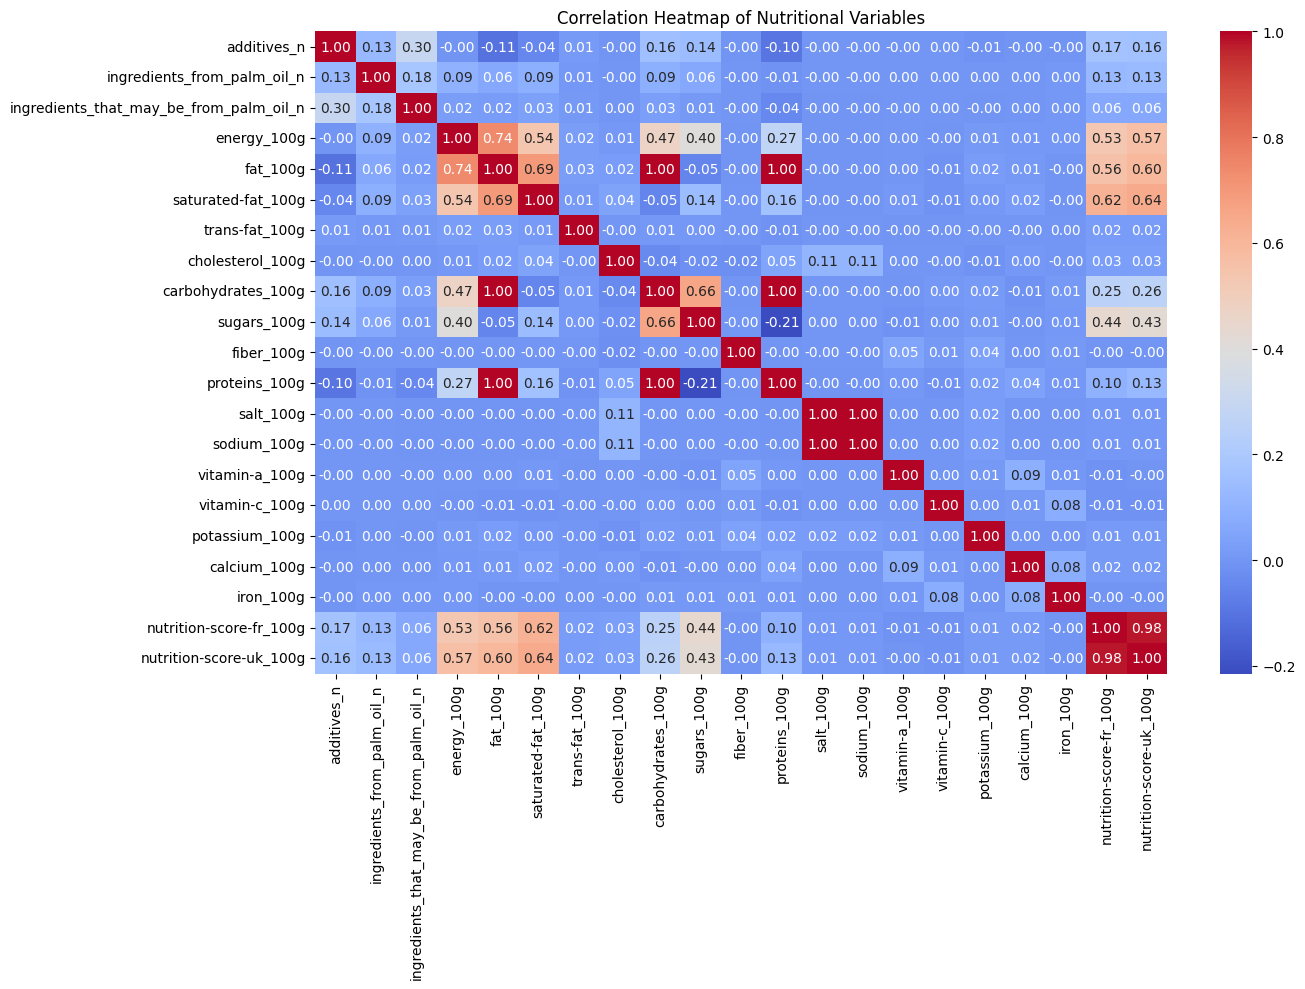

In [20]:
# Plot the correlation heatmap

plt.figure(figsize = (14, 10))
sns.heatmap(correlation_matrix, cmap = "coolwarm", annot = True, fmt = ".2f")
plt.title("Correlation Heatmap of Nutritional Variables")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap highlights several meaningful relationships among the nutritional variables. Nutrition Score (FR) and Nutrition Score (UK) exhibit an almost perfect positive correlation, indicating that both scoring systems measure nutritional quality in a highly similar manner. Energy content is strongly associated with fat and saturated fat, while carbohydrates show a strong positive relationship with sugars. Most vitamin and mineral variables display weak correlations with other nutritional attributes, suggesting that they vary independently across food products. Overall, the heatmap provides valuable insight into the relationships between major nutritional components and product quality indicators.

## Top Countries by Number of Products

Understanding the geographic distribution of products provides insight into which countries contribute the largest number of food products in the OpenFoodFacts database. This analysis identifies the most frequently occurring countries in the cleaned dataset.

In [21]:
# Count the top 15 countries with the highest number of products

top_countries = (eda_df["countries_en"].dropna().value_counts().head(15))
top_countries

countries_en
United States         173159
France                123961
Switzerland            14932
Germany                 8470
Spain                   5529
United Kingdom          5092
Belgium                 2936
Australia               2201
Russia                  1582
France,Switzerland      1492
Italy                   1433
Canada                   973
Belgium,France           759
Portugal                 738
Netherlands              628
Name: count, dtype: int64

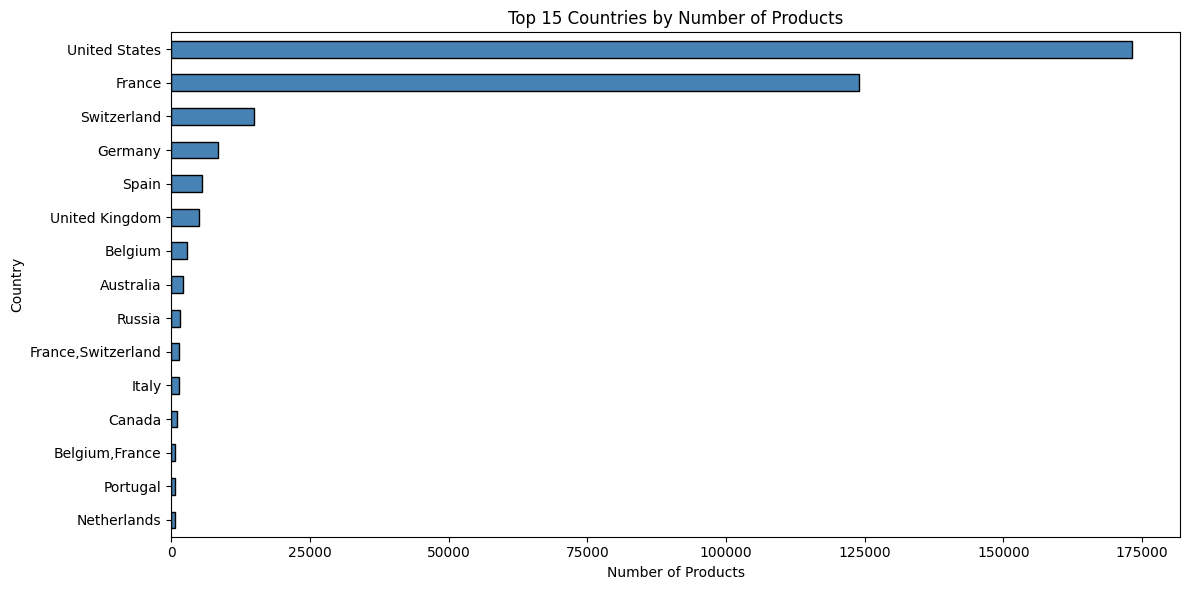

In [22]:
# Visualize the top 15 countries

plt.figure(figsize = (12, 6))
top_countries.sort_values().plot(kind = "barh", color = "steelblue", edgecolor = "black")
plt.title("Top 15 Countries by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Observation

The bar chart shows the countries contributing the highest number of products to the OpenFoodFacts dataset. A small number of countries account for a substantial proportion of the available records, indicating an uneven geographic distribution. This reflects higher participation, data availability, or product coverage from these countries within the OpenFoodFacts community.

## Top Brands by Number of Products

Brand information helps identify the manufacturers with the largest number of products in the dataset. This analysis highlights the most frequently occurring brands and provides an overview of brand representation in the OpenFoodFacts database.

In [23]:
# Count the top 15 brands

top_brands = (eda_df["brands"].dropna().value_counts().head(15))
top_brands

brands
Carrefour        3670
Auchan           3217
U                2608
Casino           2091
Leader Price     2015
Meijer           1995
Kroger           1662
Cora             1374
Ahold            1370
Spartan          1341
Roundy's         1299
Great Value      1233
Picard           1128
Weis             1053
Target Stores     947
Name: count, dtype: int64

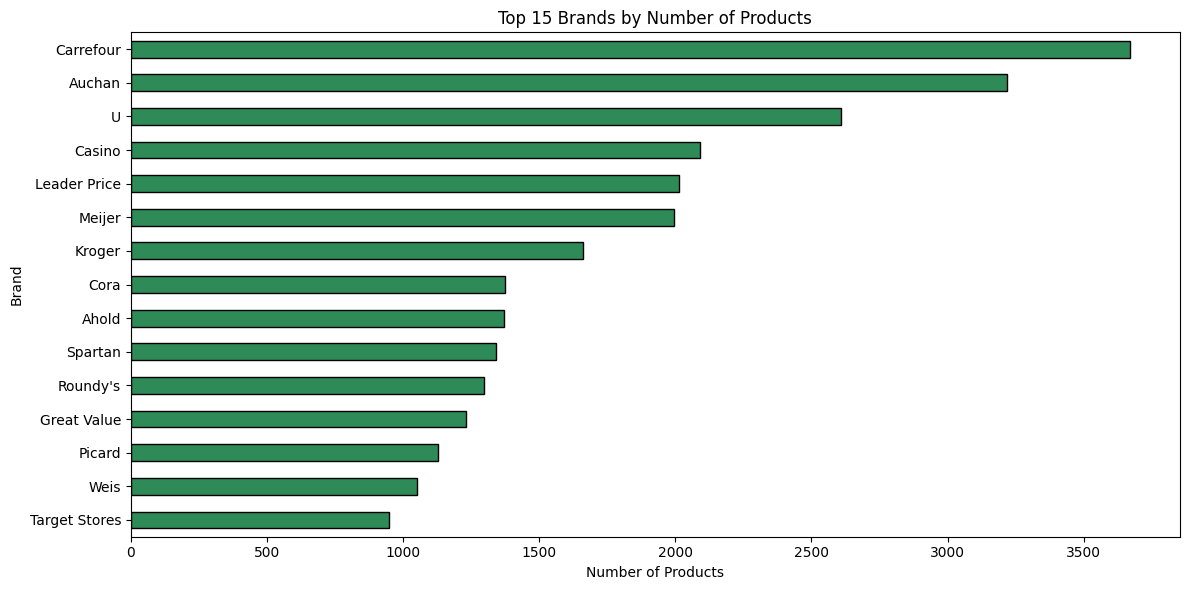

In [24]:
# Visualize the top 15 brands

plt.figure(figsize = (12, 6))
top_brands.sort_values().plot(kind = "barh", color = "seagreen", edgecolor = "black")
plt.title("Top 15 Brands by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

### Observation

The visualization highlights the brands with the highest number of products in the dataset. A few brands contribute a significantly larger number of products than others, indicating stronger representation within the OpenFoodFacts database. The distribution also shows that product availability is concentrated among a relatively small set of well-represented brands.

## Distribution of Nutrition Grades

The nutrition grade provides an overall assessment of the nutritional quality of food products, ranging from Grade A (healthiest) to Grade E (least healthy). Analyzing the distribution of nutrition grades helps understand the overall nutritional profile of the products included in the dataset.

In [25]:
# Count the distribution of nutrition grades

nutrition_grade_counts = (eda_df["nutrition_grade_fr"].dropna().str.upper().value_counts().sort_index())
nutrition_grade_counts

nutrition_grade_fr
A    40304
B    39010
C    52870
D    72436
E    50236
Name: count, dtype: int64

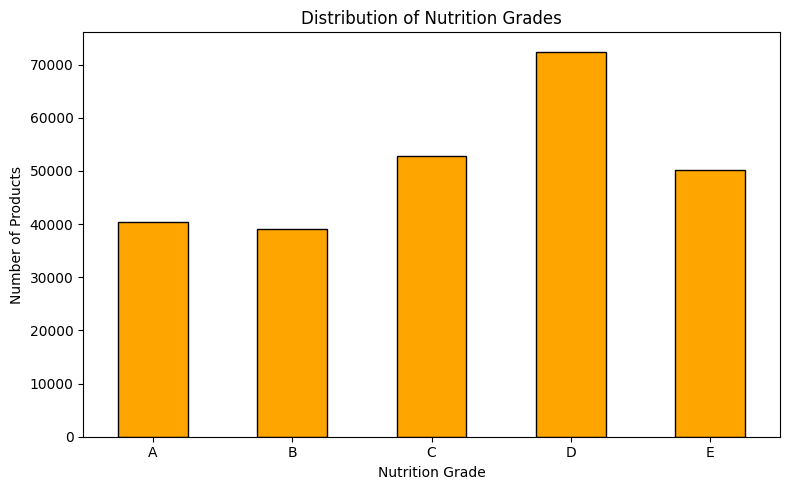

In [26]:
# Visualize nutrition grade distribution

plt.figure(figsize = (8, 5))
nutrition_grade_counts.plot(kind = "bar", color = "orange", edgecolor = "black")
plt.title("Distribution of Nutrition Grades")
plt.xlabel("Nutrition Grade")
plt.ylabel("Number of Products")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

### Observation

The distribution of nutrition grades illustrates the nutritional quality of products available in the dataset. Products are distributed across Grades A to E, indicating varying levels of nutritional value. This analysis provides an overview of how healthy or less healthy the food products are according to the Nutri-Score classification system and highlights the overall balance of nutritional quality within the dataset.

## Top Food Categories

Food categories group products into different types such as beverages, snacks, dairy products, and cereals. Identifying the most common categories provides insight into the composition of the OpenFoodFacts dataset and highlights which product groups are most frequently represented.

In [27]:
# Count the top 15 food categories

top_categories = (eda_df["categories_en"].dropna().value_counts().head(15))
top_categories

categories_en
Beverages,Non-sugared beverages                                 2345
Sugary snacks,Biscuits and cakes,Biscuits                        893
Fats                                                             732
Sugary snacks,Chocolates,Dark chocolates                         678
Sugary snacks,Confectioneries,Candies                            587
Groceries,Sauces,Tomato sauces,Ketchup                           561
Salty snacks,Appetizers,Crackers                                 534
Dairies,Milks                                                    504
Sugary snacks,Biscuits and cakes,Biscuits,Chocolate biscuits     498
Sugary snacks,Chocolates,Milk chocolates                         487
Beverages,Alcoholic beverages,Beers                              476
Dairies,Yogurts                                                  459
Sugary snacks,Chocolates                                         440
Groceries,Sauces                                                 435
Meats,Prepared meats

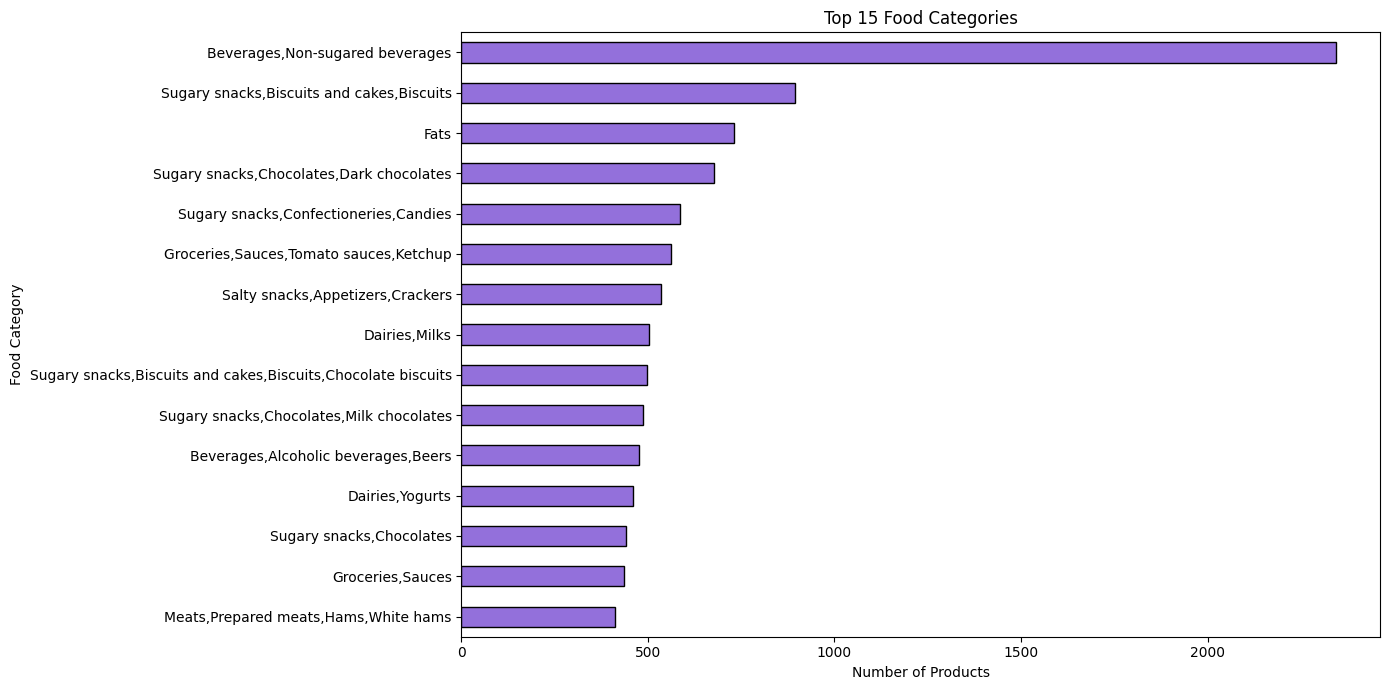

In [28]:
# Visualize the top 15 food categories

plt.figure(figsize = (14, 7))
top_categories.sort_values().plot(kind = "barh", color = "mediumpurple", edgecolor = "black")
plt.title("Top 15 Food Categories")
plt.xlabel("Number of Products")
plt.ylabel("Food Category")
plt.tight_layout()
plt.show()

### Observation

The chart presents the most frequently occurring food categories in the dataset. A relatively small number of categories account for a significant share of products, indicating that certain food groups are more extensively documented than others. This distribution provides an overview of the dominant product types available in the OpenFoodFacts database.

## Distribution of PNNS Food Groups

The PNNS (Programme National Nutrition Santé) food groups classify products into broad nutritional categories such as beverages, fruits, cereals, dairy products, and snacks. Analyzing the distribution of these groups provides a high-level overview of the types of food products represented in the dataset.

In [29]:
# Count products in each PNNS food group

pnns_counts = (eda_df["pnns_groups_1"].dropna().value_counts())
pnns_counts

pnns_groups_1
unknown                    43603
Sugary snacks              14750
Beverages                  13476
Milk and dairy products    10733
Cereals and potatoes       10078
Fish Meat Eggs              9473
Composite foods             7972
Fat and sauces              7122
Fruits and vegetables       6763
Salty snacks                3299
fruits-and-vegetables       1098
sugary-snacks                619
cereals-and-potatoes          19
salty-snacks                   1
Name: count, dtype: int64

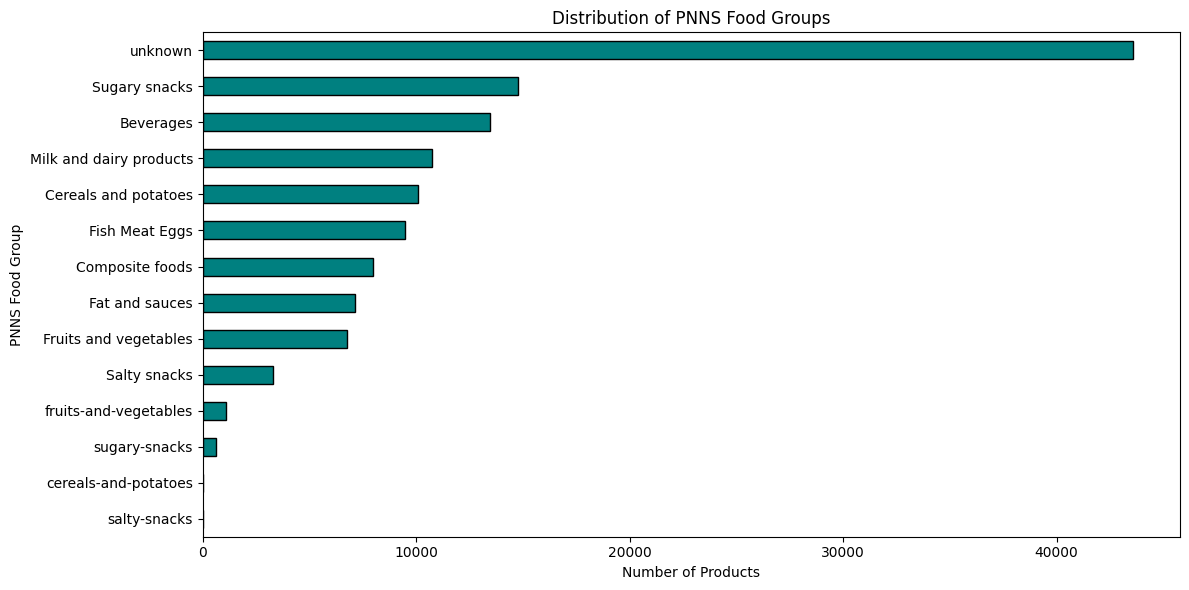

In [30]:
# Visualize PNNS food group distribution

plt.figure(figsize = (12, 6))
pnns_counts.sort_values().plot(kind = "barh", color = "teal", edgecolor = "black")
plt.title("Distribution of PNNS Food Groups")
plt.xlabel("Number of Products")
plt.ylabel("PNNS Food Group")
plt.tight_layout()
plt.show()

### Observation

The PNNS food group distribution summarizes the broad nutritional categories represented in the OpenFoodFacts dataset. Some food groups contain substantially more products than others, indicating that the dataset is more comprehensive for certain types of food. This analysis provides a useful overview of the dataset composition and highlights the diversity of products across nutritional groups.

## Distribution of PNNS Food Sub-Groups

The PNNS (Programme National Nutrition Santé) Level 2 classification provides a more detailed categorization of food products within each major food group. Analyzing these sub-groups offers deeper insight into the types of products represented in the OpenFoodFacts dataset.

In [31]:
# Count products in each PNNS Level 2 food sub-group

pnns2_counts = (eda_df["pnns_groups_2"].dropna().value_counts())
pnns2_counts

pnns_groups_2
unknown                             43603
Non-sugared beverages                7290
One-dish meals                       6495
Sweets                               5685
Biscuits and cakes                   5511
Cereals                              4686
Cheese                               4564
Dressings and sauces                 4522
Milk and yogurt                      4251
Processed meat                       3835
Alcoholic beverages                  3609
Chocolate products                   3554
Vegetables                           3159
Fish and seafood                     3070
Sweetened beverages                  2983
Fats                                 2600
Appetizers                           2464
Fruits                               2419
Fruit juices                         2349
Bread                                2337
Meat                                 1950
Breakfast cereals                    1760
Legumes                              1098
vegetables          

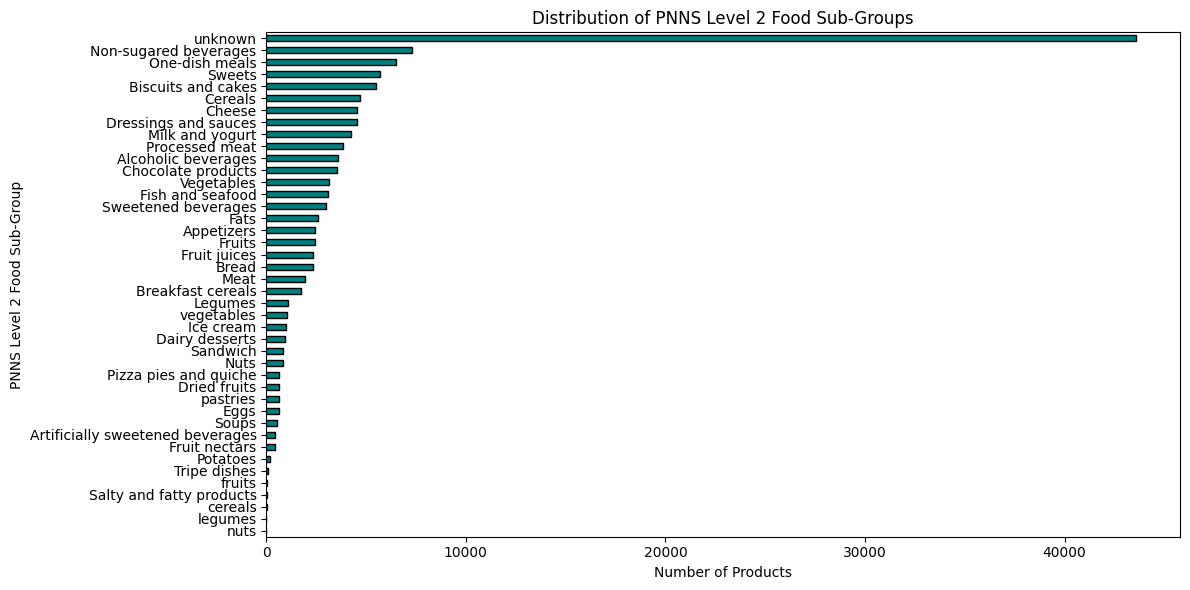

In [32]:
# Visualize PNNS Level 2 food sub-group distribution

plt.figure(figsize = (12, 6))
pnns2_counts.sort_values().plot(kind = "barh", color = "teal", edgecolor = "black")
plt.title("Distribution of PNNS Level 2 Food Sub-Groups")
plt.xlabel("Number of Products")
plt.ylabel("PNNS Level 2 Food Sub-Group")
plt.tight_layout()
plt.show()

### Observation

The PNNS Level 2 food sub-group distribution provides a more detailed view of the food products contained in the dataset. Certain food sub-groups are represented much more frequently than others, indicating that the dataset contains a higher concentration of specific product types. This analysis complements the PNNS Level 1 distribution by revealing finer-grained patterns in food classification.

# Exploratory Data Analysis Summary

The exploratory data analysis provided a comprehensive understanding of the cleaned OpenFoodFacts dataset. Numerical variables were examined through descriptive statistics, missing value analysis, histograms, boxplots, and correlation analysis, revealing the overall distribution of nutritional attributes and relationships among them.

Categorical analysis highlighted the most represented countries, brands, food categories, nutrition grades, and both **PNNS Level 1 food groups** and **PNNS Level 2 food sub-groups**. The results indicate that the dataset is dominated by products from a small number of countries and brands, while nutritional quality and food classifications vary considerably across products.

Overall, the exploratory analysis establishes a strong foundation for the next stage of the project, where advanced visualizations and actionable insights will be generated from the dataset.

In [33]:
print("Exploratory Data Analysis Summary")
print("-" * 40)
print(f"Dataset Shape                 : {eda_df.shape}")
print(f"Numerical Variables           : {len(numerical_columns)}")
print(f"Categorical Variables         : {len(categorical_columns)}")
print(f"Top Country                   : {top_countries.index[0]}")
print(f"Top Brand                     : {top_brands.index[0]}")
print(f"Most Common Nutrition Grade   : {nutrition_grade_counts.idxmax()}")
print(f"Most Common PNNS Level 1 Group: {pnns_counts.index[0]}")
print(f"Most Common PNNS Level 2 Group: {pnns2_counts.index[0]}")

Exploratory Data Analysis Summary
----------------------------------------
Dataset Shape                 : (356027, 64)
Numerical Variables           : 21
Categorical Variables         : 43
Top Country                   : United States
Top Brand                     : Carrefour
Most Common Nutrition Grade   : D
Most Common PNNS Level 1 Group: unknown
Most Common PNNS Level 2 Group: unknown
